In [1]:
import numpy as np #importing 'numpy' library which contains functions to process numerical operations
import pandas as pd #importing the 'pandas' library which contains functions to process a database
import matplotlib.pyplot as plt #importing this for ploting graphs


In [2]:
data = pd.read_csv("Salary_Data.csv") # Assign the data to a variable named "data"

In [3]:
data # viewing the stored data in the variable

,YearsExperience,Salary
0,1.1,39343.0
1,1.3,46205.0
2,1.5,37731.0
3,2.0,43525.0
4,2.2,39891.0
5,2.9,56642.0
6,3.0,60150.0
7,3.2,54445.0
8,3.2,64445.0
9,3.7,57189.0


In [4]:
independent = data[["YearsExperience"]] #storing the X variable, datatype=float
dependent = data[["Salary"]] #storing the y variable, datatype=float

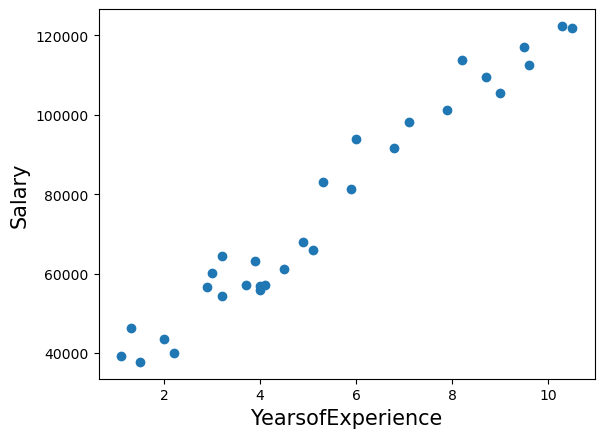

In [5]:
#Using 'scatter' function from the matplotlib.pyplot library, creating the X, y graph
plt.scatter(independent,dependent) #assigning the X, y variable to the scatter function
plt.xlabel("YearsofExperience",fontsize=15) #labelling the X variable
plt.ylabel("Salary",fontsize=15) #labelling the y variable
plt.show() #viewing the graph

In [6]:
# from 'sklearn' library, calling the 'model_selection' and importing the 'train_test_split'
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(independent,dependent,test_size=1/3,random_state=0) 
#assigning the X, y variable into 'train_test_split' function
#and splitting the data into four parts which are named as 'X_train','X_test','y_train'&'y_test'

In [7]:
y_test #viewing the test data which is splitted into 1/3rd of the original data

,Salary
2,37731.0
28,122391.0
13,57081.0
10,63218.0
26,116969.0
24,109431.0
27,112635.0
11,55794.0
17,83088.0
22,101302.0


In [8]:
#creating the linear regression model
from sklearn.linear_model import LinearRegression #importing the LinearRegression function from sklearn.linear_model
regressor = LinearRegression() #assigning the function into a variable
regressor.fit(X_train,y_train) #fitting the splitted data, here using the equation (y=w*X1+b0) we will get b1 and b0. 

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [9]:
#for viewing the b1 and b0 (weight, b1 and bias, b0)
weight = regressor.coef_ # 'coef_' is nothing but 'weight'
print("Weight of the model={}".format(weight))
bias = regressor.intercept_ # 'intercept_' is nothing but 'bias'
print("Intercept of the model={}".format(bias))

Weight of the model=[[9345.94244312]]
Intercept of the model=[26816.19224403]


In [10]:
#predicting the y using the 'predict' function with X_test data
y_pred = regressor.predict(X_test)

In [11]:
y_pred #viewing predicted y values

array([[ 40835.10590871],
       [123079.39940819],
       [ 65134.55626083],
       [ 63265.36777221],
       [115602.64545369],
       [108125.8914992 ],
       [116537.23969801],
       [ 64199.96201652],
       [ 76349.68719258],
       [100649.1375447 ]])

In [12]:
#Evaluating the model by importing the r2_score function from'sklearn.metrics'
from sklearn.metrics import r2_score
r_score = r2_score(y_test, y_pred) #insering the 'y_test' and 'y_pred' data into r2_score function
r_score #viewing the 'r2 score'

0.9749154407708353

In [13]:
#saving the model by importing the 'pickle' library
import pickle
filename = 'finalized_model.sav'
pickle.dump(regressor, open(filename, 'wb')) #'pickle.dump' is used to store the finalized model(regressor) in the assigned 'filename'
# 'wb' node ensures the file is written as binary data


In [14]:
#loading the model for checking
loaded_model = pickle.load(open('finalized_model.sav', 'rb')) #'pickle.load' is used to load the finalized model
# 'rb' mode is used for reading the saved file

In [15]:
#using the loaded model, we can predict the Salary data for given input(YearsofExperience)
required_year = int(input("Enter the years of Experience:"))
result = loaded_model.predict([[required_year]])
print(result)#printing the predicted salary

Enter the years of Experience: 12


[[138967.5015615]]


C:\Users\ADMIN\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
